In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\Pranati\OneDrive - Cornell University\Documents\BEE4750-GitHub\hw4-pp444hw4`


In [3]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (Total: 3 Points)

Solve the following linear program **analytically**. Show your work and
justify any reasoning.

$$
\begin{alignedat}{2}
&& \max_{x, y} \quad & 3x + 2y\\
&&\text{subject to:} \quad & x + 4y \leq 16\\
& && x - 2y \leq -1\\
& && 0 \leq x \leq 4\\
& && 1 \leq y \leq 4.
\end{alignedat}
$$

### Problem 2 (12 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

#### Problem 2.1

Formulate a linear program for this resource allocation problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations). **Tip:
Make sure that all of your constraints are linear**.

#### Problem 2.2

How many ha should the farmer dedicate to each crop and with what
pesticide application rate(s)? How much profit will the farmer expect to
make?

#### Problem 2.3

The farmer has an opportunity to buy an extra 10 ha of land. How much
extra profit would this land be worth to the farmer? Discuss why this
value makes sense and under what conditions you would recommend the
farmer should make the purchase.

### Problem 2 (15 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

#### Problem 1

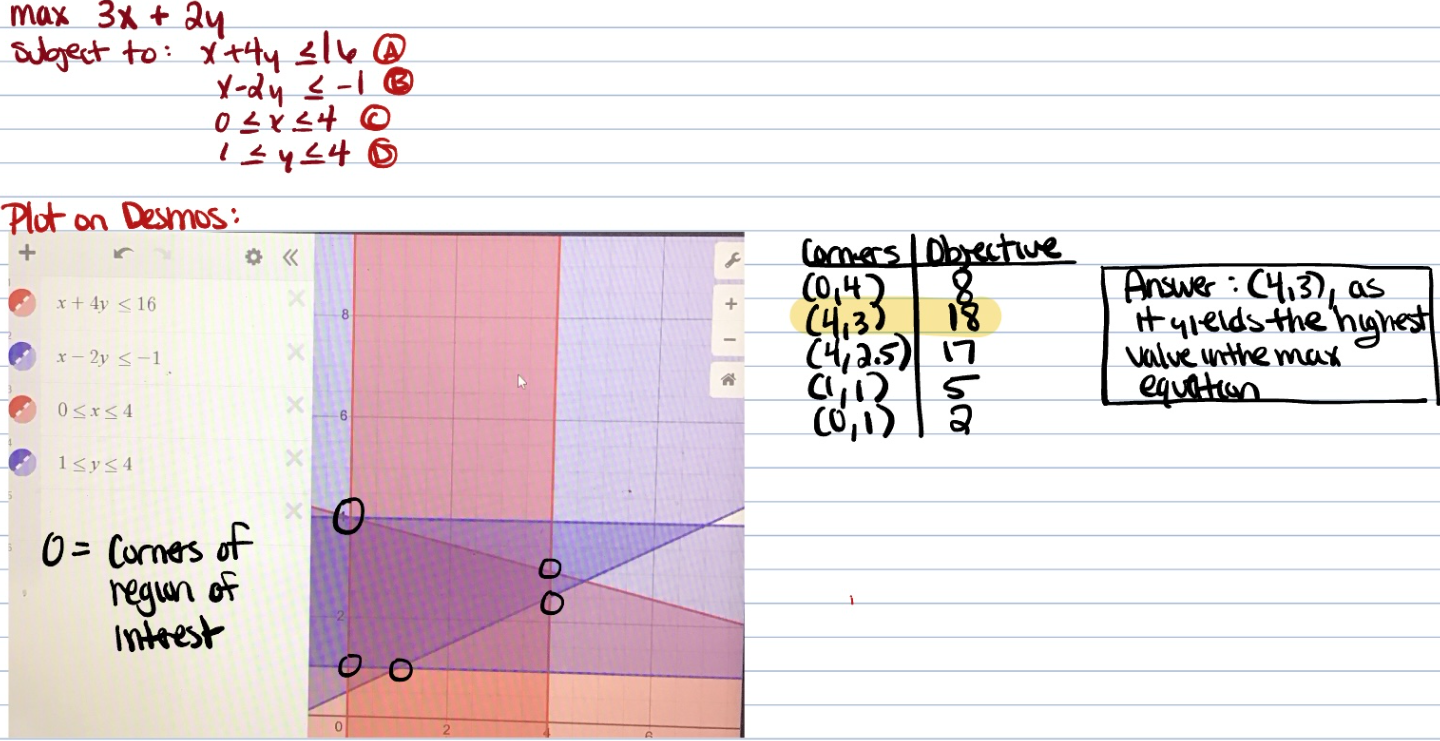

##### Problem 2

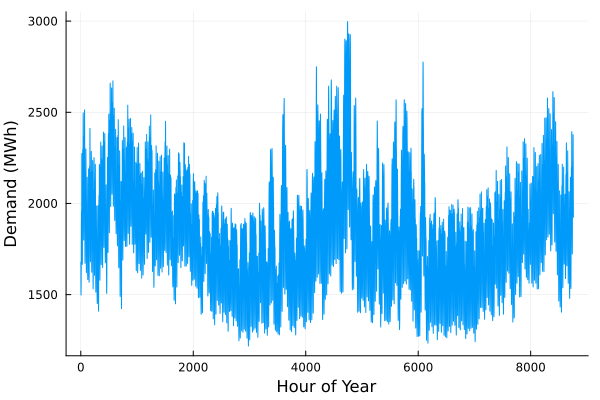

In [4]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [5]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

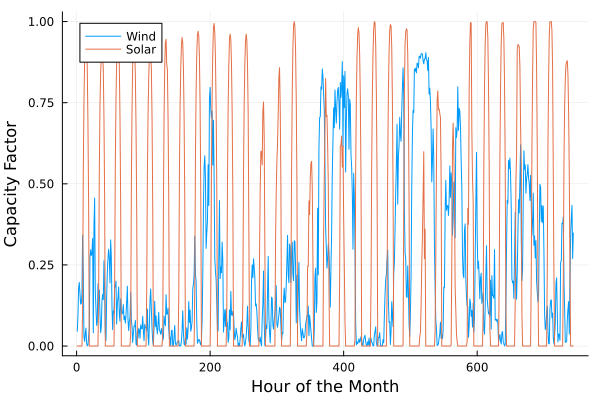

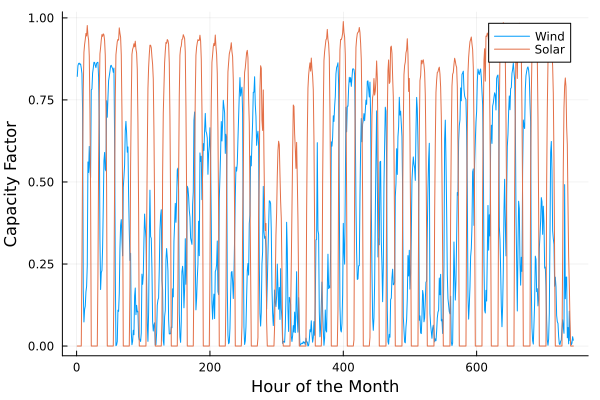

In [6]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

##### Problem 2

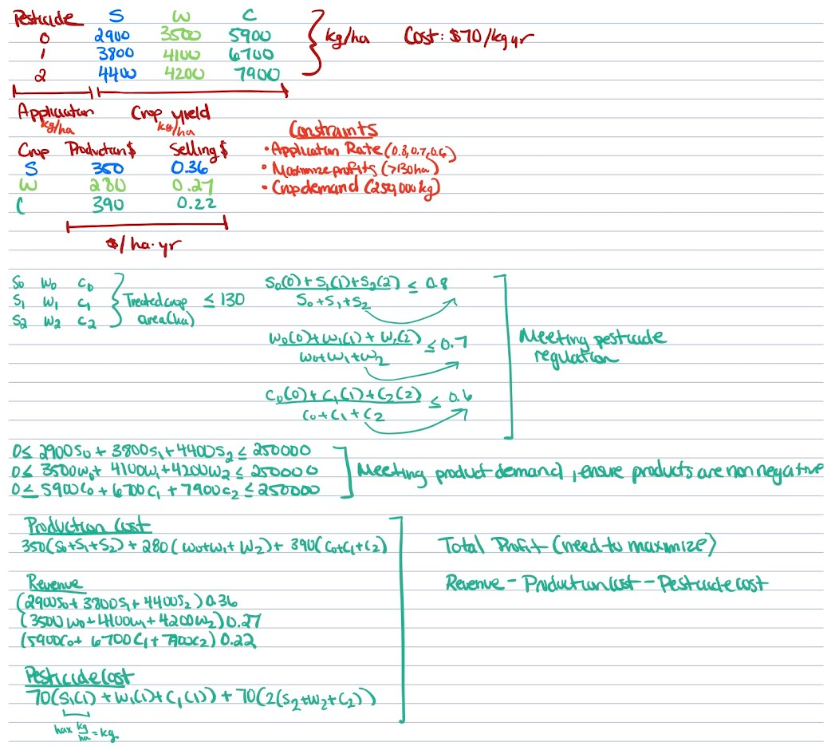

In [40]:
farm_model = Model(HiGHS.Optimizer)

#initialize each crop area as a variable
@variable(farm_model, crop[1:9] >= 0) #make sure crop area is not negative
s0 = crop[1]
s1 = crop[2]
s2 = crop[3]
w0 = crop[4]
w1 = crop[5]
w2 = crop[6]
c0 = crop[7]
c1 = crop[8]
c2 = crop[9]

s_sum = s0 + s1 + s2
w_sum = w0 + w1 + w2
c_sum = c0 + c1 + c2

#objective to maximize profit
ProdCost = 350*(s0 + s1 + s2) + 280*(w0 + w1 + w2) + 390*(c0 + c1 + c2)
Rev = 0.36*(2900*s0 + 3800*s1 + 4400*s2) + 0.27*(3500*w0 + 4100*w1 + 4200*w2) + 0.22(5900*c0 + 6700*c1 + 7900*c2)
PestCost = 70*(s1 + w1 + c1 + 2*(s2 + w2 + c2)) #ignore s0, w0, and c0 since no pesticide is applied
@objective(farm_model, Max, Rev - ProdCost - PestCost)

#constraints
#meet crop area max + non negative
@constraint(farm_model, Crop_Area, (s_sum + w_sum + c_sum) <= 130) 
#meet pesticide regulations
@constraint(farm_model, Soybean_Pesticide_Application, (s0*0 + s1*1 + s2*2) <= 0.8*s_sum) 
@constraint(farm_model, Wheat_Pesticide_Application, (w0*0 + w1*1 + w2*2) <= 0.7*w_sum) 
@constraint(farm_model, Corn_Pesticide_Application, (c0*0 + c1*1 + c2*2) <= 0.6*c_sum)
#meet product demand + non negative
@constraint(farm_model, Soybean_Demand, 0 <= 2900*s0 + 3800*s1 + 4400*s2 <= 250000)
@constraint(farm_model, Wheat_Demand, 0 <= 3500*w0 + 4100*w1 + 4200*w2 <=250000)
@constraint(farm_model, Corn_Demand, 0 <= 5900*c0 + 6700*c1 + 7900*c2 <= 250000)

print(farm_model)
optimize!(farm_model)

Max 694 crop[1] + 948 crop[2] + 1094 crop[3] + 665.0000000000001 crop[4] + 757 crop[5] + 714 crop[6] + 908 crop[7] + 1014 crop[8] + 1208 crop[9]
Subject to
 Crop_Area : crop[1] + crop[2] + crop[3] + crop[4] + crop[5] + crop[6] + crop[7] + crop[8] + crop[9] <= 130
 Soybean_Pesticide_Application : -0.8 crop[1] + 0.19999999999999996 crop[2] + 1.2 crop[3] <= 0
 Wheat_Pesticide_Application : -0.7 crop[4] + 0.30000000000000004 crop[5] + 1.3 crop[6] <= 0
 Corn_Pesticide_Application : -0.6 crop[7] + 0.4 crop[8] + 1.4 crop[9] <= 0
 Soybean_Demand : 2900 crop[1] + 3800 crop[2] + 4400 crop[3] in [0, 250000]
 Wheat_Demand : 3500 crop[4] + 4100 crop[5] + 4200 crop[6] in [0, 250000]
 Corn_Demand : 5900 crop[7] + 6700 crop[8] + 7900 crop[9] in [0, 250000]
 crop[1] >= 0
 crop[2] >= 0
 crop[3] >= 0
 crop[4] >= 0
 crop[5] >= 0
 crop[6] >= 0
 crop[7] >= 0
 crop[8] >= 0
 crop[9] >= 0
Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7 rows; 9 cols; 27 n

In [41]:
#2.2
#Dedicated Crop Area
@show value.(crop);

#Allocated pestcide application
@show shadow_price.(Soybean_Pesticide_Application);
@show shadow_price.(Wheat_Pesticide_Application);
@show shadow_price.(Corn_Pesticide_Application);

#Max profit
println("Max Profit is ", @show objective_value(farm_model))

value.(crop) = [13.812154696132593, 55.24861878453038, 0.0, 6.743306417339564, 15.73438164045898, 0.0, 26.923076923076927, 0.0, 11.538461538461554]
shadow_price.(Soybean_Pesticide_Application) = 212.28176795580112
shadow_price.(Wheat_Pesticide_Application) = 91.99999999999989
shadow_price.(Corn_Pesticide_Application) = 108.67692307692312
objective_value(farm_model) = 116741.16702082448
Max Profit is 116741.16702082448


#### Problem 2.2 Write Up

According to the linea model, the allocated crop values are as follows

Soybean:<br>
s0 = 13.8 ha<br>
s1 = 55.2 ha<br>
s2 = 0 ha<br>

Wheat:<br>
w0 = 6.7 ha<br>
w1 = 15.7 ha<br>
w2 = 0 ha<br>

Corn:<br>
c0 = 26.9 ha<br>
c1 = 0 ha<br>
c2 = 11.5 ha<br>

In terms of total crop allocated pesticide applications, soybean was 212.3 kg/ha, wheat was 92.0 kg/ha, and corn was 108.7 kg/ha

In terms of total profit, the farmers get about $116,741.17

In [42]:
#2.3
@show shadow_price(Crop_Area)

shadow_price(Crop_Area) = 729.4000000000001


729.4000000000001

#### Problem 2.3 Write Up

As seen from the model, the shadow price of the total crop areas is 729.4, representing the amount the solution (profit) would increase per unit (ha). Therefore, if we increase by 10 units of ha, the profit would increase by 729.4*10 dollars, or $7,294. Rerunning the model with the increased ha in the constraint actually showed the profit to go up by this number.

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.
The NY state legislature is planning to enact an annual CO<sub>2</sub>
limit, which for the utility would limit the emissions in its footprint
to 1.5 MtCO<sub>2</sub>/yr.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

#### Problem 3.1

Formulate a linear program for this capacity expansion problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations).

#### Problem 3.2

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?

#### Problem 3.3

What fraction of annual generation does each plant type produce? How
does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?

#### Problem 3.4

Make a plot of the electricity price in each hour. Discuss any trends
that you see.

#### Problem 3.5

What is the shadow price of CO<sub>2</sub>? What is the value to the
utility be of allowing it to emit an additional 1000 tCO<sub>2</sub>/yr?

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

#### 3.1
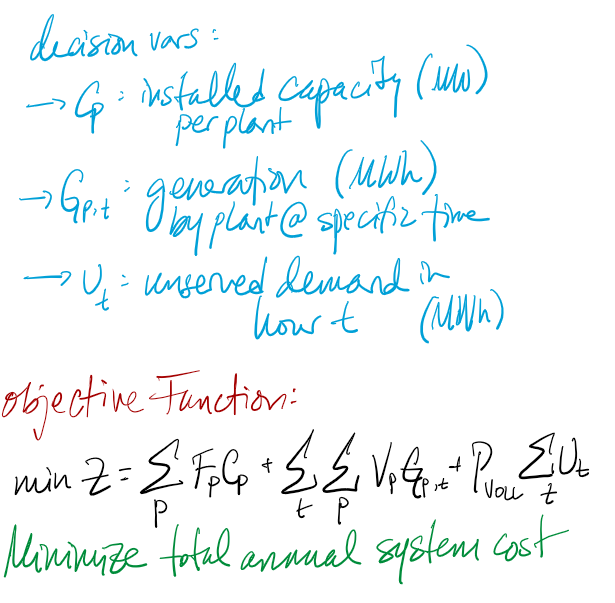
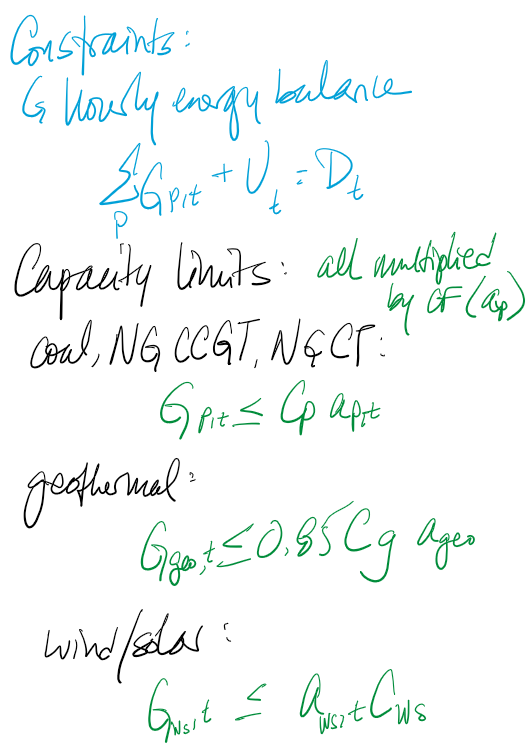
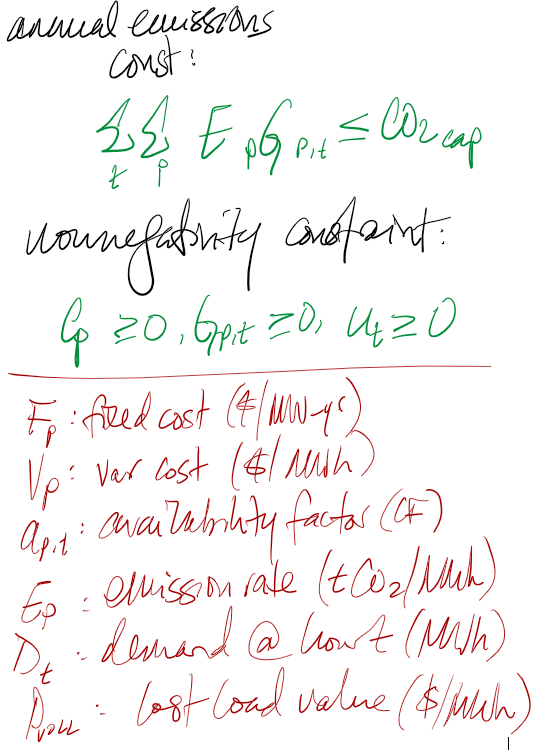

In [26]:
#3.2
#loading data -- the VSCode notebook helped with syntax

demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(demand, :"Time Stamp" => :Date)
rename!(demand, :C => :Demand)
demand.Hour = 1:nrow(demand)
numHours = nrow(demand)

gens = DataFrame(CSV.File("data/generators.csv"))
CF = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
plants = gens.Plant

availability = Dict(
    "Geothermal" => fill(0.85, numHours),
    "Coal"       => fill(1.0, numHours),
    "NG CCGT"    => fill(1.0, numHours),
    "NG CT"      => fill(1.0, numHours),
    "Wind"       => CF.Wind,
    "Solar"      => CF.Solar
)

CO2cap = 1.5e6
penalty = 10000.0

fixed = Dict(gens.Plant .=> gens.FixedCost)
var = Dict(gens.Plant .=> gens.VarCost)
emi = Dict(gens.Plant .=> gens.Emissions)

#optimization model
model = Model(HiGHS.Optimizer)

@variable(model, C[p in plants] >= 0) 
@variable(model, G[p in plants, t in 1:numHours] >= 0)
@variable(model, U[t in 1:numHours] >= 0)

@objective(model, Min, 
    sum(fixed[p] * C[p] for p in plants) +
    sum(var[p] * G[p,t] for p in plants, t in 1:numHours) +
    penalty * sum(U[t] for t in 1:numHours)
)

#constraints
for t in 1:numHours
    @constraint(model, 
        sum(G[p,t] for p in plants) + U[t] == demand.Demand[t]
    )
end

#capacity limit
for p in plants, t in 1:numHours
    @constraint(model, 
        G[p,t] <= C[p] * availability[p][t])
end

#CO2 emissions constraint
@constraint(model, co2_limit, sum(emi[p] * G[p,t] for p in plants, t in 1:numHours) <= CO2cap)


#solve
optimize!(model)


Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 61321 rows; 61326 cols; 188256 nonzeros
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
56857 rows, 56862 cols, 179328 nonzeros  0s
Presolve : Reductions: rows 56857(-4464); columns 56862(-4464); elements 179328(-8928)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(5.18855e+06) 0s
      20724     4.5856896406e+08 Pr: 10167(5.2419e+06); Du: 0(1.88022e-07) 5s
      26975     7.0089057297e+08 Pr: 9694(4.55027e+06); Du: 0(7.07016e-08) 11s
      29777     7.7328394995e+08 Pr: 10324(3.2

In [36]:
println("total system cost = ", objective_value(model))
println("total unserved energy = ", sum(value.(U)))

println("installed capacity (MW)")
for p in plants
    println(p, ": ", value(C[p]))
end

total system cost = 7.853529589434898e8
total unserved energy = 332.2907137925929
installed capacity (MW)
Geothermal: 285.568135230671
Coal: 0.0
NG CCGT: 1509.1728698942966
NG CT: 703.0618976373753
Wind: 2548.887923366492
Solar: 2103.7493968268923


##### 3.2

We see an annual system cost of ~7.58 x 10^8 dollars, with around 330 MWh of unserved energy

geothermal (285 MW), NG CCGT (1500 MW), NG CT (700 MW), Wind (2550 MW), solar (2100 MW), Coal (0 MW)

solution basically prioritizes both renewable and natural gas technologies because of lower emissions and competitive costs. Coal was essentially excluded under the CO2 cap. Wind and solar are supplying most of the total energy, and so it's assumed that combustion turbines would cover peak hours.

In [ ]:
#3.3

genTotal = Dict()
for p in plants
    genTotal[p] = sum(value.(G[p,t]) for t in 1:numHours)
end

totalGen = sum(values(genTotal))
totalCap = sum(value.(C))

for p in plants
    genShare = genTotal[p] / totalGen * 100
    capShare = value(C[p]) / totalCap * 100
    println(rpad(p, 20), lpad(round(genShare, digits=2), 10), lpad(round(capShare, digits=2), 15))
end

Geothermal                 6.7           3.99
Coal                       0.0            0.0
NG CCGT                   20.3          21.11
NG CT                     0.79           9.83
Wind                     39.42          35.65
Solar                    32.79          29.42


##### 3.3

Wind and solar provide more than 70% of total generation, which is good because it confirms that renewables dominate under the CO2 cap. The capacity shares are high because of the variable output and lower CFs. NG CCGT contributes ~20% of total generation, which shows that it's in a middle merit source (a good in between). NG CT plants hold ~10% of installed capacity but operate rarely becauses they are probably used as peaking units. Finally, geothermal provides a small but pretty consistent baseload contribution. Coal is excluded due to high CO2 emissions.

Overall, the results show a system where renewables and a little bit of gas generation jointly satisfy the demand while meeting the emissions limits at minimum cost.

In [ ]:
#3.5
#shadow price
dualVal = abs(dual(co2_limit))

println("Shadow price of CO2 constraint: \$", round(dualVal, digits=2), " per tonne of CO2")

#multiply by 1000 tonnes
valThousand = dualVal * 1000.0
println("Value of allowing 1000 more tonnes of CO2 emissions per year = \$", round(valThousand, digits=2))


Shadow price of CO2 constraint: $182.77 per tonne of CO2
Value of allowing 1000 more tonnes of CO2 emissions per year = $182771.94


##### 3.5

The dual values of the CO2 cap is about $182 per tCO2. I had to put it in the absolute value function because the Jump <= function. 

If we allowed an additional 1000t of CO2 per year, it would reduce total cost by roughly 182000 dollars per year. 

The show prices basically shows the marginal implicit carbon price -- it also shows or quantifies the trade-off between cleaner generation and total economic cost in this energy optimization problem.

## References

List any external references consulted, including classmates.

Emma Pereira

The built-in code fillers in VSCode also helped with syntax (mainly rounding and formatting)